# Preprocessing Dataset CSE-CIC-IDS2018

**Proyek:** Sistem Deteksi Intrusi Berbasis Machine Learning  
**Dataset:** CSE-CIC-IDS2018 (Communications Security Establishment & Canadian Institute for Cybersecurity)  
**Output:** `dataset_split.joblib`

---

## Prinsip Desain

1. **Netral antar model** — tidak ada feature selection berbasis algoritma tertentu. Ketiga model menerima input identik sehingga perbandingan bersifat *fair*.
2. **Anti-leakage** — semua keputusan yang bergantung pada distribusi data (varians, korelasi, scaling) hanya di-*fit* dari data training.
3. **Berbasis data aktual** — setiap keputusan penanganan (inf, duplikat, dll.) diambil setelah audit distribusi label.
4. **Mendukung target sistem** — F1 ≥ 85%, FPR ≤ 2%.

---

## Keputusan Berbasis Data Aktual

| Tahap | Keputusan | Justifikasi dari Data |
|---|---|---|
| Penanganan inf | Cap P99 | 98,6% dari 95.760 baris inf berasal dari Benign — replace max finite akan menaikkan FPR |
| Dedup | Hanya kelas Benign | Dedup penuh menghancurkan FTP-BruteForce (99,97% hilang) dan SlowHTTPTest (99,96% hilang) karena serangan ini repetitif by design |
| Stratified split | Berdasarkan label multiclass | SQL Injection hanya 87 sampel — stratify binary bisa menghasilkan distribusi 87-0-0 |
| Scaling | QuantileTransformer uniform | std Bwd Pkts/s = 92.686 (outlier ekstrem) — MinMax/Standard tidak robust |

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Sel 1 — Instalasi dan Impor Library

In [1]:
!pip install polars --quiet

import polars as pl
import numpy as np
import pandas as pd
import os, gc, joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.utils import class_weight
from itertools import combinations

print("Polars versi:", pl.__version__)

dataset_path = "/content/drive/MyDrive/Colab Notebooks"

csv_files = [
    "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-23-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
]

RANDOM_STATE = 42
print(f"Total file CSV: {len(csv_files)}")

Polars versi: 1.35.2
Total file CSV: 10


---
## Setup Visualisasi (EDA)
Sel ini hanya menambahkan library dan konfigurasi plot. Tidak mengubah variabel preprocessing apapun.

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'font.family'      : 'DejaVu Serif',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 200,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

_CLR_BENIGN = '#2166AC'
_CLR_ATTACK = '#D6604D'
_SAVE_PATH  = dataset_path

print('Setup visualisasi siap.')


Setup visualisasi siap.


---
## Sel 2 — Inspeksi Schema Per File

In [6]:
columns_per_file = {}
for f in csv_files:
    path = os.path.join(dataset_path, f)
    lf   = pl.scan_csv(path, n_rows=0)
    cols = [c.strip() for c in lf.collect_schema().names()]
    columns_per_file[f] = cols
    print(f"{f}: {len(cols)} kolom")

common_cols = set(columns_per_file[csv_files[0]])
for f in csv_files[1:]:
    common_cols &= set(columns_per_file[f])
common_cols = sorted(common_cols)
print(f"\nKolom umum di semua file: {len(common_cols)}")

Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv: 80 kolom
Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv: 80 kolom
Friday-16-02-2018_TrafficForML_CICFlowMeter.csv: 80 kolom
Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv: 84 kolom
Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv: 80 kolom
Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv: 80 kolom
Friday-23-02-2018_TrafficForML_CICFlowMeter.csv: 80 kolom
Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv: 80 kolom
Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv: 80 kolom
Friday-02-03-2018_TrafficForML_CICFlowMeter.csv: 80 kolom

Kolom umum di semua file: 80


---
## Sel 2a — Profil Dataset: Isi per File CSV

Dataset CSE-CIC-IDS2018 terdiri dari 10 file CSV yang direkam selama periode **14 Februari — 2 Maret 2018** di lingkungan jaringan Canadian Institute for Cybersecurity. Setiap file merepresentasikan satu hari pengambilan data dengan skenario serangan yang berbeda.

Sel ini membaca **setiap file secara individual** (tanpa penggabungan) untuk menampilkan:
- Hari dan tanggal pengambilan data
- Jenis serangan yang disimulasikan
- Jumlah baris Benign dan Attack secara terpisah

> **Catatan:** Sel ini bersifat **read-only** — tidak ada modifikasi data apapun.


In [7]:
import warnings, re
warnings.filterwarnings('ignore')

_DAY_ID = {
    'monday':'Senin', 'tuesday':'Selasa', 'thuesday':'Selasa',
    'wednesday':'Rabu', 'thursday':'Kamis', 'friday':'Jumat',
    'saturday':'Sabtu', 'sunday':'Minggu'
}

def _parse_filename(fname):
    _m = re.match(r'([A-Za-z]+)-(\d{2})-(\d{2})-(\d{4})', fname)
    if _m:
        _day_en  = _m.group(1).lower()
        _dd, _mm, _yyyy = _m.group(2), _m.group(3), _m.group(4)
        _bulan = {
            '01':'Januari','02':'Februari','03':'Maret','04':'April',
            '05':'Mei','06':'Juni','07':'Juli','08':'Agustus',
            '09':'September','10':'Oktober','11':'November','12':'Desember'
        }
        _hari    = _DAY_ID.get(_day_en, _day_en.capitalize())
        _tanggal = f'{int(_dd)} {_bulan.get(_mm, _mm)} {_yyyy}'
        return _hari, _tanggal
    return '?', '?'

print('=' * 90)
print(' PROFIL DATASET CSE-CIC-IDS2018 — PER FILE CSV (SEBELUM PENGGABUNGAN)')
print('=' * 90)
print('  Dataset merekam trafik jaringan nyata selama 14 Februari — 2 Maret 2018')
print('  Lingkungan: Canadian Institute for Cybersecurity, University of New Brunswick')
print()

_summary_rows = []

for _no, _fname in enumerate(csv_files, 1):
    _fpath        = os.path.join(dataset_path, _fname)
    _hari, _tgl   = _parse_filename(_fname)
    _n_cols       = len(columns_per_file.get(_fname, []))

    _df_tmp = pl.scan_csv(
        _fpath, infer_schema_length=0, ignore_errors=True
    ).select(
        pl.col('Label').str.strip_chars()
    ).filter(
        pl.col('Label') != 'Label'
    ).with_columns(
        pl.col('Label').str.replace('Infilteration', 'Infiltration')
    ).collect()

    _n_total  = _df_tmp.height
    _n_benign = _df_tmp.filter(pl.col('Label').str.to_lowercase() == 'benign').height
    _n_attack = _n_total - _n_benign
    _pct_b    = _n_benign / _n_total * 100 if _n_total > 0 else 0
    _pct_a    = _n_attack / _n_total * 100 if _n_total > 0 else 0

    _dist_tmp = (
        _df_tmp
        .filter(pl.col('Label').str.to_lowercase() != 'benign')
        .group_by('Label')
        .agg(pl.len().alias('n'))
        .sort('n', descending=True)
        .to_pandas()
    )
    # Simpan sebagai list untuk dipakai di visualisasi
    _attack_list   = _dist_tmp['Label'].tolist() if len(_dist_tmp) > 0 else []
    _attack_detail = ', '.join(
        [f"{r['Label']} ({r['n']:,})" for _, r in _dist_tmp.iterrows()]
    ) if len(_dist_tmp) > 0 else 'Tidak ada attack'

    print(f'[{_no:02d}] {_hari}, {_tgl}')
    print(f'     File    : {_fname}')
    print(f'     Kolom   : {_n_cols}')
    print(f'     Total   : {_n_total:,} baris')
    print(f'     Benign  : {_n_benign:,} ({_pct_b:.1f}%)')
    print(f'     Attack  : {_n_attack:,} ({_pct_a:.1f}%)')
    print(f'     Detail  : {_attack_detail}')
    print()

    _summary_rows.append({
        'No'         : _no,
        'Hari'       : _hari,
        'Tanggal'    : _tgl,
        'Total Baris': _n_total,
        'Benign'     : _n_benign,
        'Attack'     : _n_attack,
        '% Benign'   : f'{_pct_b:.1f}%',
        '% Attack'   : f'{_pct_a:.1f}%',
        'Kolom'      : _n_cols,
        '_attack_list': _attack_list,
    })
    del _df_tmp, _dist_tmp
    gc.collect()

_df_summary = pd.DataFrame(_summary_rows)

print('=' * 90)
print(' TABEL RINGKASAN')
print('=' * 90)
print(_df_summary.drop(columns=['_attack_list']).to_string(index=False))
print()
print(f'Total baris seluruh file : {_df_summary["Total Baris"].sum():,}')
print(f'Total Benign             : {_df_summary["Benign"].sum():,}')
print(f'Total Attack             : {_df_summary["Attack"].sum():,}')

del _summary_rows
gc.collect()

 PROFIL DATASET CSE-CIC-IDS2018 — PER FILE CSV (SEBELUM PENGGABUNGAN)
  Dataset merekam trafik jaringan nyata selama 14 Februari — 2 Maret 2018
  Lingkungan: Canadian Institute for Cybersecurity, University of New Brunswick

[01] Rabu, 14 Februari 2018
     File    : Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
     Kolom   : 80
     Total   : 1,048,575 baris
     Benign  : 667,626 (63.7%)
     Attack  : 380,949 (36.3%)
     Detail  : FTP-BruteForce (193,360), SSH-Bruteforce (187,589)

[02] Kamis, 15 Februari 2018
     File    : Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
     Kolom   : 80
     Total   : 1,048,575 baris
     Benign  : 996,077 (95.0%)
     Attack  : 52,498 (5.0%)
     Detail  : DoS attacks-GoldenEye (41,508), DoS attacks-Slowloris (10,990)

[03] Jumat, 16 Februari 2018
     File    : Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
     Kolom   : 80
     Total   : 1,048,574 baris
     Benign  : 446,772 (42.6%)
     Attack  : 601,802 (57.4%)
     Detail  : DoS

0

---
### Visualisasi Profil Per File CSV
Gambar berikut menampilkan komposisi Benign vs Attack untuk setiap file CSV secara visual, sehingga distribusi serangan per hari dapat dibandingkan secara langsung.


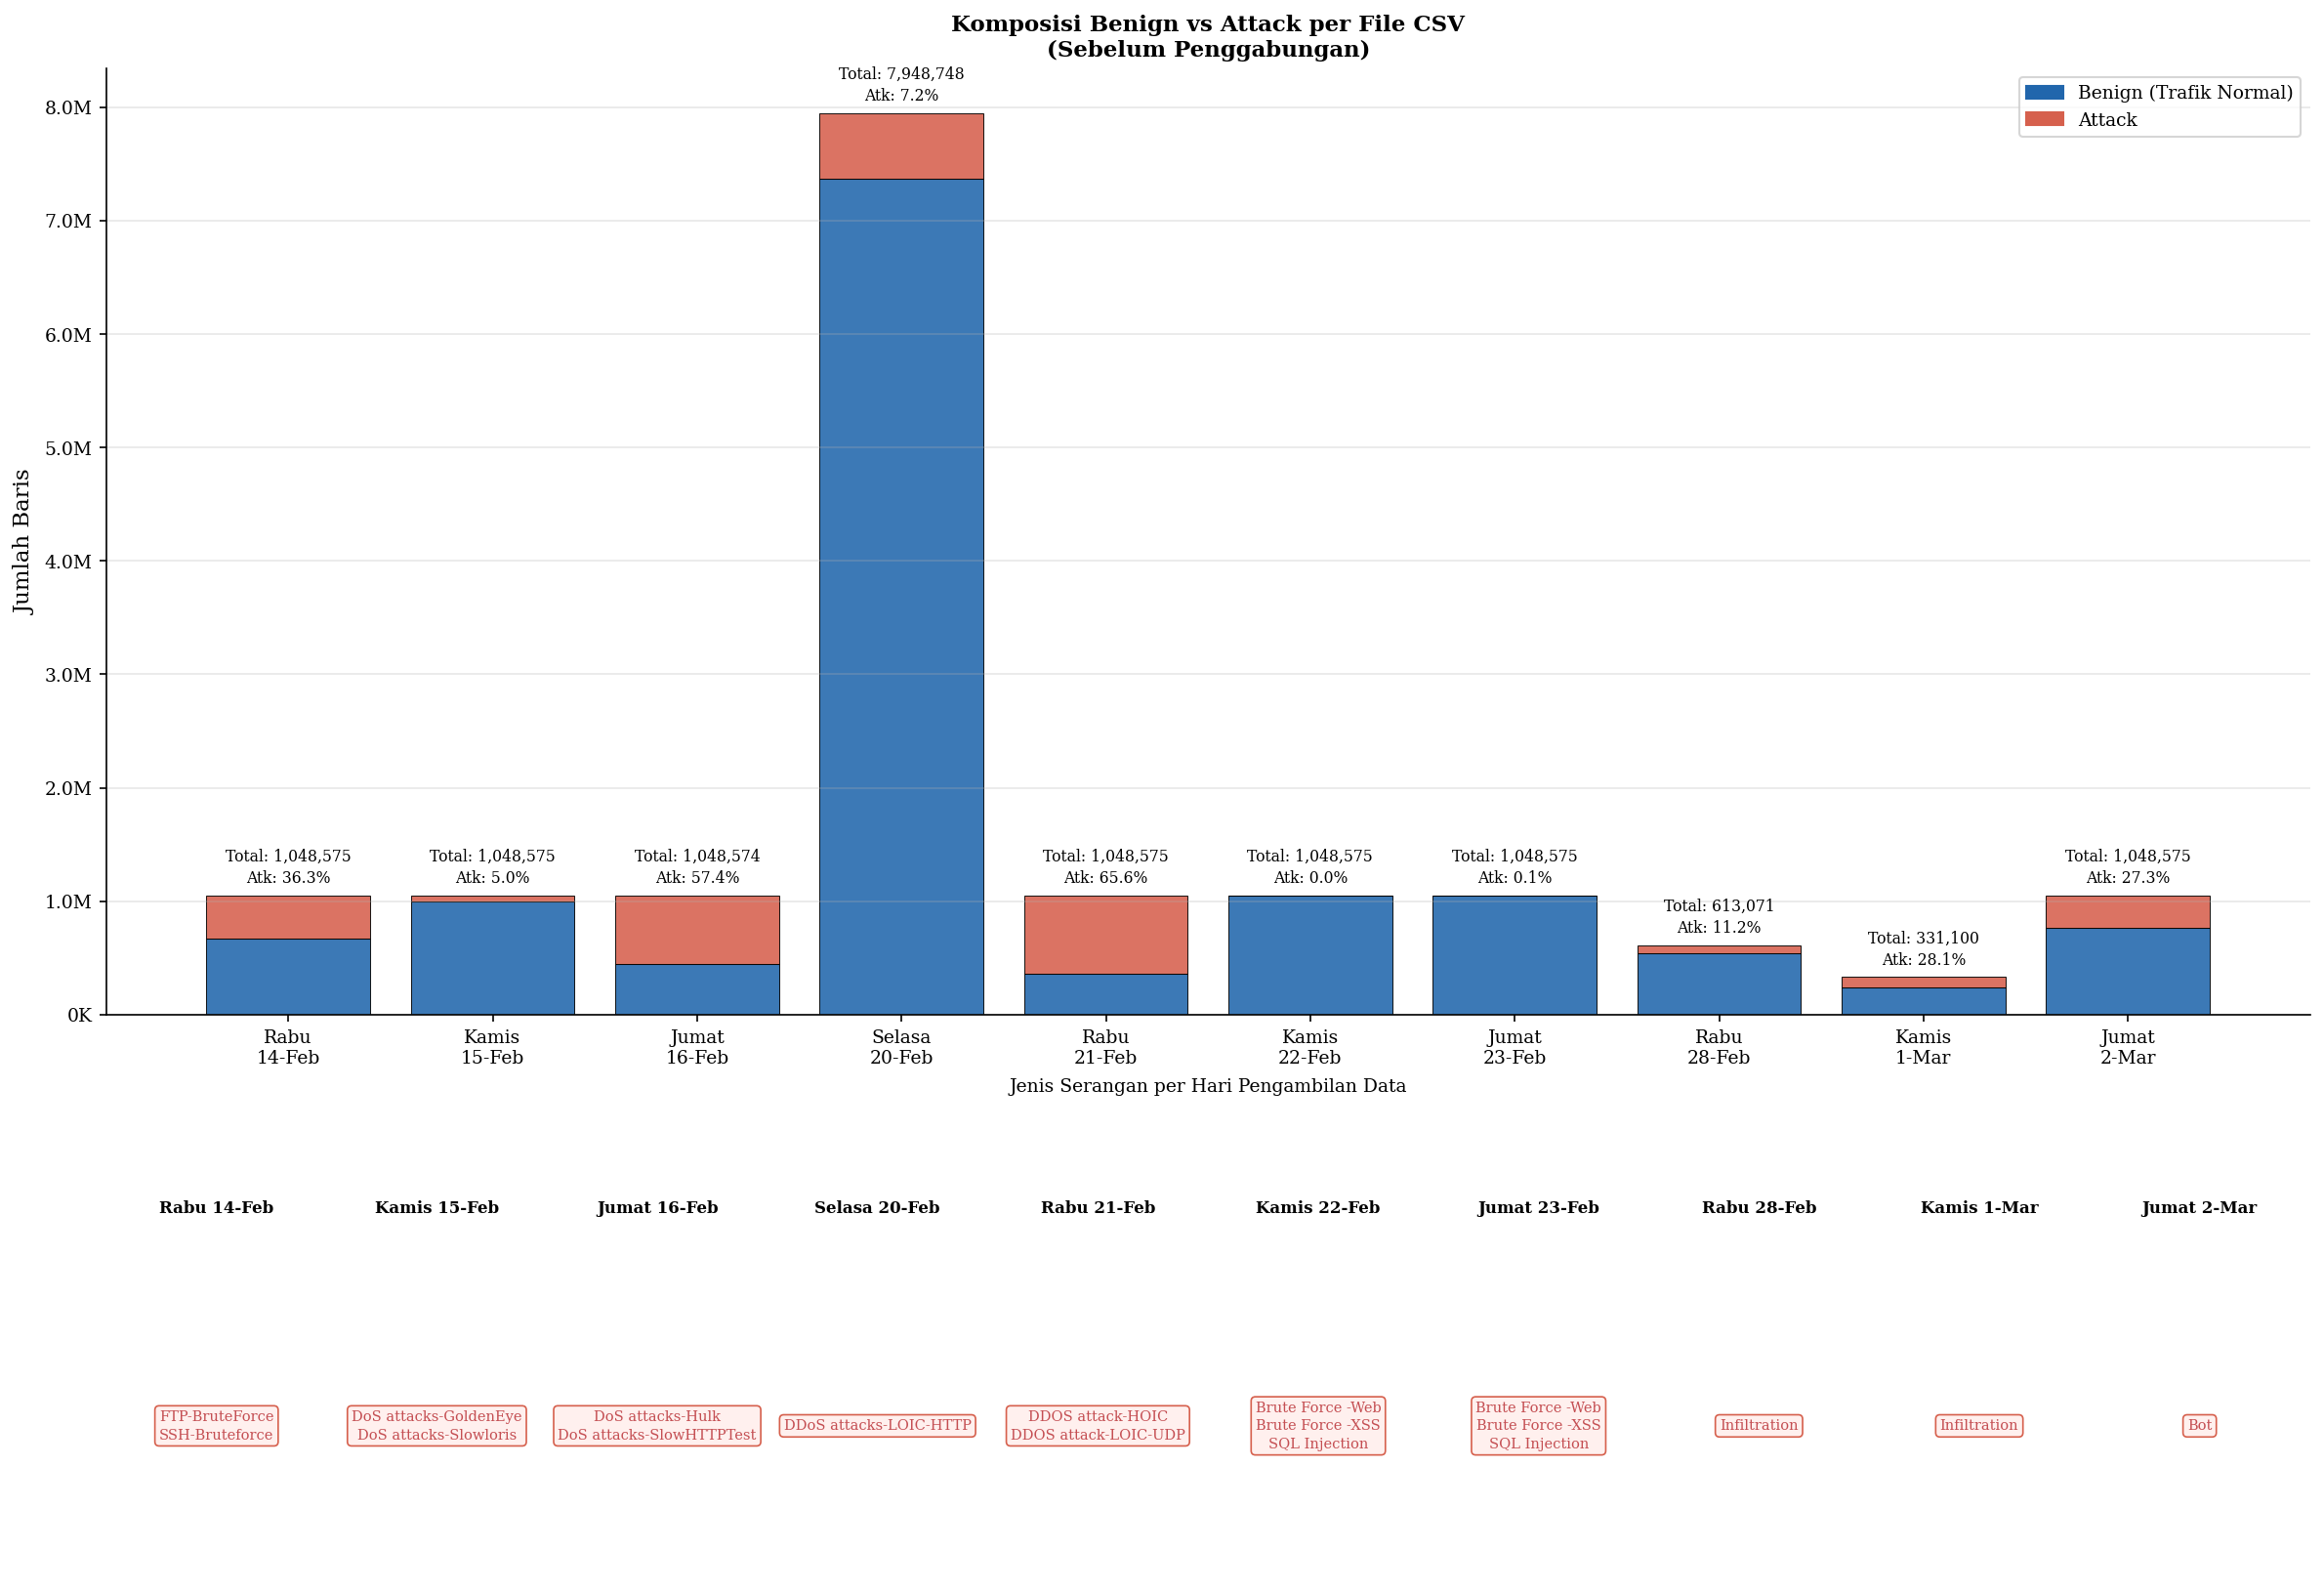

Gambar tersimpan: EDA_00_profil_per_file_csv.png


0

In [8]:
_labels_short = [
    f"{row['Hari']}\n{row['Tanggal'].split()[0]}-{row['Tanggal'].split()[1][:3]}"
    for _, row in _df_summary.iterrows()
]

_serangan_label = [
    '\n'.join(row['_attack_list']) if row['_attack_list'] else 'Benign Only'
    for _, row in _df_summary.iterrows()
]

_benign_vals = _df_summary['Benign'].tolist()
_attack_vals = _df_summary['Attack'].tolist()
_total_vals  = _df_summary['Total Baris'].tolist()
_x           = np.arange(len(_df_summary))

fig, axes = plt.subplots(2, 1, figsize=(16, 11),
                          gridspec_kw={'height_ratios': [2, 1]})

_b1 = axes[0].bar(_x, _benign_vals,
                  color=_CLR_BENIGN, alpha=0.88,
                  edgecolor='black', linewidth=0.5, label='Benign')
_b2 = axes[0].bar(_x, _attack_vals, bottom=_benign_vals,
                  color=_CLR_ATTACK, alpha=0.88,
                  edgecolor='black', linewidth=0.5, label='Attack')

for _i, (_t, _a) in enumerate(zip(_total_vals, _attack_vals)):
    _pct = _a / _t * 100 if _t > 0 else 0
    axes[0].text(
        _i, _t + max(_total_vals) * 0.01,
        f'Total: {_t:,}\nAtk: {_pct:.1f}%',
        ha='center', va='bottom', fontsize=7.5, linespacing=1.4
    )

axes[0].set_xticks(_x)
axes[0].set_xticklabels(_labels_short, fontsize=9)
axes[0].set_ylabel('Jumlah Baris')
axes[0].set_title(
    'Komposisi Benign vs Attack per File CSV\n'
    '(Sebelum Penggabungan)',
    fontsize=11, fontweight='bold'
)
axes[0].yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda v, _: f'{v/1_000_000:.1f}M' if v >= 1_000_000
                     else f'{v/1_000:.0f}K'
    )
)
axes[0].legend(handles=[
    mpatches.Patch(color=_CLR_BENIGN, label='Benign (Trafik Normal)'),
    mpatches.Patch(color=_CLR_ATTACK, label='Attack'),
], fontsize=9, loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

axes[1].set_xlim(-0.5, len(_df_summary) - 0.5)
axes[1].set_ylim(0, 1)
axes[1].axis('off')

for _i, (_lbl, _atk) in enumerate(zip(_labels_short, _serangan_label)):
    axes[1].text(
        _i, 0.78, _lbl.replace('\n', ' '),
        ha='center', va='center', fontsize=8, fontweight='bold'
    )
    axes[1].text(
        _i, 0.32, _atk,
        ha='center', va='center', fontsize=7,
        color='#C44E52', linespacing=1.4,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF0EE',
                  edgecolor=_CLR_ATTACK, linewidth=0.8)
    )

axes[1].set_title(
    'Jenis Serangan per Hari Pengambilan Data',
    fontsize=9
)

plt.tight_layout(h_pad=0.5)
plt.savefig(os.path.join(_SAVE_PATH, 'EDA_00_profil_per_file_csv.png'))
plt.show()
print('Gambar tersimpan: EDA_00_profil_per_file_csv.png')

del _b1, _b2, _labels_short, _serangan_label
del _benign_vals, _attack_vals, _total_vals, _x
del _i, _t, _a, _pct, _lbl, _atk
gc.collect()

---
## Sel 2b — Eksplorasi Awal Dataset

Sebelum melakukan tindakan apapun, dilakukan eksplorasi awal untuk memahami:
- Struktur dan tipe data kolom
- Sampel baris awal (*head*) dan statistik deskriptif
- Kolom-kolom yang perlu dihapus pada tahap berikutnya beserta alasannya

**Catatan:** Sel ini bersifat **read-only** — tidak ada penghapusan, pengubahan, atau penyimpanan data.

### Mengapa ada kolom berbeda (80 vs 84 kolom)?
File `Thuesday-20-02-2018` memiliki 84 kolom karena CICFlowMeter pada tanggal tersebut menghasilkan kolom tambahan yang tidak konsisten dengan file lain. Oleh karena itu, hanya **80 kolom umum** (*common columns*) yang digunakan agar seluruh file dapat digabungkan tanpa risiko ketidakcocokan atribut.

### Mengapa kolom identitas dihapus?
Kolom berikut bersifat **identitas jaringan** bukan **statistik trafik**:
| Kolom | Alasan Dihapus |
|---|---|
| `Dst Port` | Port tujuan adalah label layanan, bukan perilaku trafik |
| `Protocol` | Nomor protokol (TCP=6, UDP=17) — tidak relevan sebagai fitur statistik |
| `Timestamp` | Cap waktu absolut — menyebabkan *data leakage* temporal |
| `Flow ID` | ID unik per flow — tidak mengandung informasi perilaku |
| `Src IP` | Alamat IP sumber — spesifik per environment, tidak generalisasi |
| `Dst IP` | Alamat IP tujuan — sama seperti Src IP |
| `Src Port` | Port sumber ephemeral — acak, bukan sinyal serangan |

Penghapusan ini mencegah **label leakage** dan memastikan model belajar dari **perilaku statistik trafik**, bukan dari identitas jaringan spesifik.

In [9]:
import warnings
warnings.filterwarnings('ignore')

_sample_file = os.path.join(dataset_path, csv_files[0])
_df_sample   = pl.read_csv(_sample_file, n_rows=5000, infer_schema_length=0,
                            ignore_errors=True)
_df_sample   = _df_sample.rename({c: c.strip() for c in _df_sample.columns})

print('=' * 70)
print(f' EKSPLORASI AWAL — {csv_files[0]}')
print('=' * 70)

print(f'\n[1] INFORMASI UMUM')
print(f'    Jumlah baris (sampel) : {_df_sample.height:,}')
print(f'    Jumlah kolom          : {_df_sample.width}')
print(f'    Estimasi ukuran       : {_df_sample.estimated_size()/1024:.1f} KB')

print(f'\n[2] TIPE DATA KOLOM ({_df_sample.width} kolom)')
_dtypes_df = pl.DataFrame({
    'Kolom'    : _df_sample.columns,
    'Tipe Data': [str(t) for t in _df_sample.dtypes],
})
_type_counts = _dtypes_df.group_by('Tipe Data').agg(pl.len().alias('Jumlah')).sort('Jumlah', descending=True)
print(_type_counts)

_identity_preview = ['Dst Port', 'Protocol', 'Timestamp',
                      'Flow ID', 'Src IP', 'Dst IP', 'Src Port']
_found_identity = [c for c in _identity_preview if c in _df_sample.columns]
print(f'\n[3] KOLOM IDENTITAS YANG DITEMUKAN ({len(_found_identity)} kolom)')
if _found_identity:
    print(_df_sample.select(_found_identity).head(5))
else:
    print('    (tidak ditemukan dalam sampel ini)')

_non_identity = [c for c in _df_sample.columns if c not in _identity_preview]
_show_cols    = _non_identity[:10]
print(f'\n[4] SAMPEL DATA (5 baris, 10 kolom fitur pertama dari {len(_non_identity)} kolom)')
print(_df_sample.select(_show_cols).head(5))

print(f'\n[5] DISTRIBUSI LABEL PADA FILE PERTAMA')
_label_dist = (
    _df_sample.select('Label')
    .group_by('Label')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
)
print(_label_dist)

_numeric_sample = _df_sample.select(
    [pl.col(c).cast(pl.Float32, strict=False)
     for c in _df_sample.columns
     if c not in _identity_preview + ['Label']]
).head(2000)

_stat_cols = _numeric_sample.columns[:8]
_desc = _numeric_sample.select(_stat_cols).describe()
print(f'\n[6] STATISTIK DESKRIPTIF (8 kolom pertama dari {_numeric_sample.width} kolom fitur)')
print(_desc)

print(f'\n[7] DETEKSI NILAI KHUSUS (sampel 5.000 baris)')
_float_cols_s = [c for c in _numeric_sample.columns]
_n_null = _numeric_sample.null_count().sum_horizontal().item()
_n_inf  = sum(
    _numeric_sample.filter(pl.col(c).is_infinite()).height
    for c in _float_cols_s
)
_n_neg  = sum(
    _numeric_sample.filter(pl.col(c) < 0).height
    for c in _float_cols_s
)
print(f'    Nilai null  : {_n_null:,}')
print(f'    Nilai inf   : {_n_inf:,}')
print(f'    Nilai negatif : {_n_neg:,}')

print(f'\n[8] KONSISTENSI KOLOM ANTAR FILE')
print(f'    Kolom umum di semua 10 file  : {len(common_cols)}')
for _f, _cols in columns_per_file.items():
    _diff = len(_cols) - len(common_cols)
    _mark = f'  (+{_diff} kolom ekstra)' if _diff > 0 else ''
    print(f'    {_f[:50]:<52}: {len(_cols)} kolom{_mark}')

print(f'\n[KESIMPULAN]')
print(f'  - Dataset terdiri dari {len(csv_files)} file CSV dengan total ~16 juta baris')
print(f'  - {len(_found_identity)} kolom identitas akan dihapus')
print(f'  - Kolom fitur yang tersisa: {len(common_cols) - len(_found_identity) - 1} fitur + 1 Label')

del _df_sample, _dtypes_df, _type_counts, _label_dist, _numeric_sample
del _desc, _found_identity, _non_identity, _show_cols, _stat_cols
del _float_cols_s, _n_null, _n_inf, _n_neg, _diff
import gc; gc.collect()

 EKSPLORASI AWAL — Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv

[1] INFORMASI UMUM
    Jumlah baris (sampel) : 5,000
    Jumlah kolom          : 80
    Estimasi ukuran       : 702.6 KB

[2] TIPE DATA KOLOM (80 kolom)
shape: (1, 2)
┌───────────┬────────┐
│ Tipe Data ┆ Jumlah │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ String    ┆ 80     │
└───────────┴────────┘

[3] KOLOM IDENTITAS YANG DITEMUKAN (3 kolom)
shape: (5, 3)
┌──────────┬──────────┬─────────────────────┐
│ Dst Port ┆ Protocol ┆ Timestamp           │
│ ---      ┆ ---      ┆ ---                 │
│ str      ┆ str      ┆ str                 │
╞══════════╪══════════╪═════════════════════╡
│ 0        ┆ 0        ┆ 14/02/2018 08:31:01 │
│ 0        ┆ 0        ┆ 14/02/2018 08:33:50 │
│ 0        ┆ 0        ┆ 14/02/2018 08:36:39 │
│ 22       ┆ 6        ┆ 14/02/2018 08:40:13 │
│ 22       ┆ 6        ┆ 14/02/2018 08:40:23 │
└──────────┴──────────┴─────────────────────┘

[4] SAMPEL DATA (5 baris, 10 kolom

30

---
## Sel 3 — Penghapusan Kolom Identitas (Anti-Label Leakage)

In [10]:
identity_cols = ['Dst Port', 'Protocol', 'Timestamp',
                 'Flow ID', 'Src IP', 'Dst IP', 'Src Port']
to_remove = [c for c in identity_cols if c in common_cols]
keep_cols = [c for c in common_cols if c not in to_remove]

if 'Label' not in keep_cols:
    keep_cols.append('Label')

print(f"Kolom identitas yang dihapus : {to_remove}")
print(f"Kolom yang dipertahankan     : {len(keep_cols)} (termasuk Label)")

Kolom identitas yang dihapus : ['Dst Port', 'Protocol', 'Timestamp']
Kolom yang dipertahankan     : 77 (termasuk Label)


---
## Sel 4 — Pemuatan Data CSV (String-First Strategy)

In [11]:
lazy_frames = []
for f in csv_files:
    path = os.path.join(dataset_path, f)
    print(f"Memuat {f}...")
    lf = pl.scan_csv(path, infer_schema_length=0, ignore_errors=False)

    rename_map = {c: c.strip() for c in lf.collect_schema().names()}
    lf = lf.rename(rename_map)

    available = [c for c in keep_cols if c in lf.collect_schema().names()]
    lf = lf.select(available)

    if 'Label' in available:
        lf = lf.filter(pl.col("Label") != "Label")
        lf = lf.with_columns(
            pl.col("Label").str.replace("Infilteration", "Infiltration")
        )

    lazy_frames.append(lf)
    gc.collect()

print("\nSemua lazy frame siap.")

Memuat Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv...
Memuat Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv...
Memuat Friday-16-02-2018_TrafficForML_CICFlowMeter.csv...
Memuat Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv...
Memuat Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv...
Memuat Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv...
Memuat Friday-23-02-2018_TrafficForML_CICFlowMeter.csv...
Memuat Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv...
Memuat Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv...
Memuat Friday-02-03-2018_TrafficForML_CICFlowMeter.csv...

Semua lazy frame siap.


---
## Sel 5 — Casting, Penggabungan, dan Verifikasi Data

In [12]:
non_label_cols = [c for c in keep_cols if c != 'Label']

casted_frames = []
for lf in lazy_frames:
    cols_in_frame = lf.collect_schema().names()
    lf = lf.with_columns([
        pl.col(c).cast(pl.Float32, strict=False)
        for c in non_label_cols if c in cols_in_frame
    ])
    casted_frames.append(lf)

print("Casting selesai. Menggabungkan dan mengumpulkan data...")
full_lf  = pl.concat(casted_frames)
final_df = full_lf.collect(engine="streaming")

del lazy_frames, casted_frames, full_lf
gc.collect()

print(f"Shape data  : {final_df.shape}")
print(f"Memori      : {final_df.estimated_size() / 1024**2:.1f} MB")
print("\nDistribusi Label :")
print(final_df.group_by('Label').agg(pl.len()).sort('len', descending=True))

Casting selesai. Menggabungkan dan mengumpulkan data...
Shape data  : (16232943, 77)
Memori      : 4825.0 MB

Distribusi Label :
shape: (15, 2)
┌────────────────────────┬──────────┐
│ Label                  ┆ len      │
│ ---                    ┆ ---      │
│ str                    ┆ u32      │
╞════════════════════════╪══════════╡
│ Benign                 ┆ 13484708 │
│ DDOS attack-HOIC       ┆ 686012   │
│ DDoS attacks-LOIC-HTTP ┆ 576191   │
│ DoS attacks-Hulk       ┆ 461912   │
│ Bot                    ┆ 286191   │
│ …                      ┆ …        │
│ DoS attacks-Slowloris  ┆ 10990    │
│ DDOS attack-LOIC-UDP   ┆ 1730     │
│ Brute Force -Web       ┆ 611      │
│ Brute Force -XSS       ┆ 230      │
│ SQL Injection          ┆ 87       │
└────────────────────────┴──────────┘


---
## Sel 6 — Audit Nilai Tak Hingga (Inf)

In [13]:
float_cols = [c for c in final_df.columns if final_df[c].dtype == pl.Float32]

print("=== AUDIT NILAI INF ===")
inf_cols = []
for c in float_cols:
    cnt = final_df.filter(pl.col(c).is_infinite()).height
    if cnt > 0:
        inf_cols.append(c)
        print(f"  {c}: {cnt:,} baris")

if inf_cols:
    inf_mask   = pl.any_horizontal([pl.col(c).is_infinite() for c in inf_cols])
    inf_rows   = final_df.filter(inf_mask)

    print(f"\nTotal baris unik dengan nilai inf : {inf_rows.height:,}")
    print(f"Persentase dari total             : {100*inf_rows.height/final_df.height:.3f}%")
    print("\nDistribusi label pada baris inf:")
    print(inf_rows.group_by('Label').agg(pl.len()).sort('len', descending=True))

    n_inf_benign = inf_rows.filter(pl.col('Label').str.to_lowercase() == 'benign').height
    n_inf_attack = inf_rows.height - n_inf_benign
    pct_attack   = 100 * n_inf_attack / inf_rows.height

    print(f"\nBaris inf yang merupakan ATTACK  : {n_inf_attack:,} ({pct_attack:.1f}%)")
    print(f"Baris inf yang merupakan BENIGN  : {n_inf_benign:,} ({100-pct_attack:.1f}%)")
    del inf_rows
else:
    print("Tidak ada nilai inf.")

=== AUDIT NILAI INF ===
  Flow Byts/s: 36,039 baris
  Flow Pkts/s: 95,760 baris

Total baris unik dengan nilai inf : 95,760
Persentase dari total             : 0.590%

Distribusi label pada baris inf:
shape: (3, 2)
┌────────────────┬───────┐
│ Label          ┆ len   │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ Benign         ┆ 94459 │
│ Infiltration   ┆ 1295  │
│ FTP-BruteForce ┆ 6     │
└────────────────┴───────┘

Baris inf yang merupakan ATTACK  : 1,301 (1.4%)
Baris inf yang merupakan BENIGN  : 94,459 (98.6%)


---
## Sel 7 — Penanganan Nilai Tak Hingga: Cap Persentil ke-99

In [14]:
if inf_cols:
    print("=== PENANGANAN INF: CAP PERSENTIL KE-99 ===")
    for c in inf_cols:
        p99   = final_df.filter(~pl.col(c).is_infinite())[c].quantile(0.99)
        n_inf = final_df.filter(pl.col(c).is_infinite()).height
        final_df = final_df.with_columns(
            pl.when(pl.col(c).is_infinite())
              .then(p99)
              .otherwise(pl.col(c))
              .alias(c)
        )
        print(f"  {c}: {n_inf:,} nilai inf -> P99 = {p99:,.4f}")

    inf_sisa = sum(
        final_df.filter(pl.col(c).is_infinite()).height for c in inf_cols
    )
    print(f"\nVerifikasi inf tersisa : {inf_sisa} (harus 0)")

null_total = final_df.null_count().sum_horizontal().item()
print(f"Total null             : {null_total} (harus 0)")
print(f"Shape                  : {final_df.shape}")

=== PENANGANAN INF: CAP PERSENTIL KE-99 ===
  Flow Byts/s: 36,039 nilai inf -> P99 = 1,291,666.6250
  Flow Pkts/s: 95,760 nilai inf -> P99 = 2,000,000.0000

Verifikasi inf tersisa : 0 (harus 0)
Total null             : 0 (harus 0)
Shape                  : (16232943, 77)


---
## Sel 8 — Penghapusan Nilai Negatif pada Fitur Non-Negatif

In [15]:
nonneg_cols = [
    'Flow Duration',
    'Flow IAT Mean', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Tot',   'Fwd IAT Mean', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Tot',   'Bwd IAT Mean', 'Bwd IAT Max', 'Bwd IAT Min',
]
nonneg_cols = [c for c in nonneg_cols if c in final_df.columns]

neg_mask  = pl.any_horizontal([pl.col(c) < 0 for c in nonneg_cols])
neg_count = final_df.filter(neg_mask).height
print(f"Baris dengan nilai negatif: {neg_count}")

if neg_count > 0:
    print("Distribusi label pada baris negatif:")
    print(final_df.filter(neg_mask).group_by('Label').agg(pl.len()))
    final_df = final_df.filter(~neg_mask)
    print(f"Shape setelah penghapusan: {final_df.shape}")
else:
    print("Tidak ditemukan nilai negatif. ")

Baris dengan nilai negatif: 15
Distribusi label pada baris negatif:
shape: (1, 2)
┌────────┬─────┐
│ Label  ┆ len │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ Benign ┆ 15  │
└────────┴─────┘
Shape setelah penghapusan: (16232928, 77)


---
## Sel 9 — Penanganan Sentinel Value -1 pada Init Win Byts

In [16]:
for c in ['Init Fwd Win Byts', 'Init Bwd Win Byts']:
    if c in final_df.columns:
        n_minus1 = final_df.filter(pl.col(c) == -1).height
        final_df = final_df.with_columns(
            pl.when(pl.col(c) == -1).then(0).otherwise(pl.col(c)).alias(c)
        )
        print(f"{c}: {n_minus1:,} sentinel -1 -> 0")

Init Fwd Win Byts: 4,432,594 sentinel -1 -> 0
Init Bwd Win Byts: 8,255,535 sentinel -1 -> 0


---
## Sel 10 — Penghapusan Duplikat Selektif (Hanya Kelas Benign)

In [17]:
print("=== DISTRIBUSI SEBELUM DEDUP ===")
dist_before = final_df.group_by('Label').agg(
    pl.len().alias('count')
).sort('count', descending=True)
dist_before_dict = {r['Label']: r['count'] for r in dist_before.iter_rows(named=True)}
print(dist_before)

benign_df = final_df.filter(pl.col('Label').str.to_lowercase() == 'benign')
attack_df = final_df.filter(pl.col('Label').str.to_lowercase() != 'benign')

print(f"\nBenign sebelum dedup   : {benign_df.height:,}")
print(f"Attack (tidak di-dedup): {attack_df.height:,}")

benign_deduped  = benign_df.unique()
pct_benign_dup  = 100 * (benign_df.height - benign_deduped.height) / benign_df.height
print(f"Benign setelah dedup   : {benign_deduped.height:,}")
print(f"Duplikat Benign hapus  : {benign_df.height - benign_deduped.height:,} ({pct_benign_dup:.1f}%)")

final_df = pl.concat([benign_deduped, attack_df])
del benign_df, benign_deduped, attack_df
gc.collect()

print(f"\nShape setelah dedup selektif: {final_df.shape}")
print("\nDistribusi setelah dedup:")
print(final_df.group_by('Label').agg(pl.len()).sort('len', descending=True))

=== DISTRIBUSI SEBELUM DEDUP ===
shape: (15, 2)
┌────────────────────────┬──────────┐
│ Label                  ┆ count    │
│ ---                    ┆ ---      │
│ str                    ┆ u32      │
╞════════════════════════╪══════════╡
│ Benign                 ┆ 13484693 │
│ DDOS attack-HOIC       ┆ 686012   │
│ DDoS attacks-LOIC-HTTP ┆ 576191   │
│ DoS attacks-Hulk       ┆ 461912   │
│ Bot                    ┆ 286191   │
│ …                      ┆ …        │
│ DoS attacks-Slowloris  ┆ 10990    │
│ DDOS attack-LOIC-UDP   ┆ 1730     │
│ Brute Force -Web       ┆ 611      │
│ Brute Force -XSS       ┆ 230      │
│ SQL Injection          ┆ 87       │
└────────────────────────┴──────────┘

Benign sebelum dedup   : 13,484,693
Attack (tidak di-dedup): 2,748,235
Benign setelah dedup   : 8,986,829
Duplikat Benign hapus  : 4,497,864 (33.4%)

Shape setelah dedup selektif: (11735064, 77)

Distribusi setelah dedup:
shape: (15, 2)
┌────────────────────────┬─────────┐
│ Label                  ┆ len 

---
## Sel 11 — Pembuatan Label Binary dan Checkpoint Parquet

In [18]:
final_df = final_df.with_columns(
    pl.when(pl.col("Label").str.to_lowercase() == "benign")
      .then(0).otherwise(1).cast(pl.Int8).alias("attack")
)

n_benign = final_df.filter(pl.col('attack') == 0).height
n_attack = final_df.filter(pl.col('attack') == 1).height
print("Distribusi label binary:")
print(final_df.group_by('attack').agg(pl.len()).sort('attack'))
print(f"Rasio Benign:Attack = {n_benign/n_attack:.2f}:1")

checkpoint_path = os.path.join(dataset_path, "cicids2018_cleaned.parquet")
final_df.write_parquet(checkpoint_path, compression="snappy")
print(f"\nCheckpoint disimpan : {checkpoint_path}")
print(f"Shape               : {final_df.shape}")

Distribusi label binary:
shape: (2, 2)
┌────────┬─────────┐
│ attack ┆ len     │
│ ---    ┆ ---     │
│ i8     ┆ u32     │
╞════════╪═════════╡
│ 0      ┆ 8986829 │
│ 1      ┆ 2748235 │
└────────┴─────────┘
Rasio Benign:Attack = 3.27:1

Checkpoint disimpan : /content/drive/MyDrive/Colab Notebooks/cicids2018_cleaned.parquet
Shape               : (11735064, 78)


---
## EDA-A — Distribusi Kelas Setelah Pembersihan Data
Visualisasi dilakukan setelah seluruh tahap pembersihan selesai (*deduplication*, penanganan *inf*, nilai negatif, dan sentinel). Bertujuan memverifikasi distribusi label multiclass dan mengidentifikasi tingkat ketidakseimbangan kelas (*class imbalance*) yang mempengaruhi strategi pelatihan model.

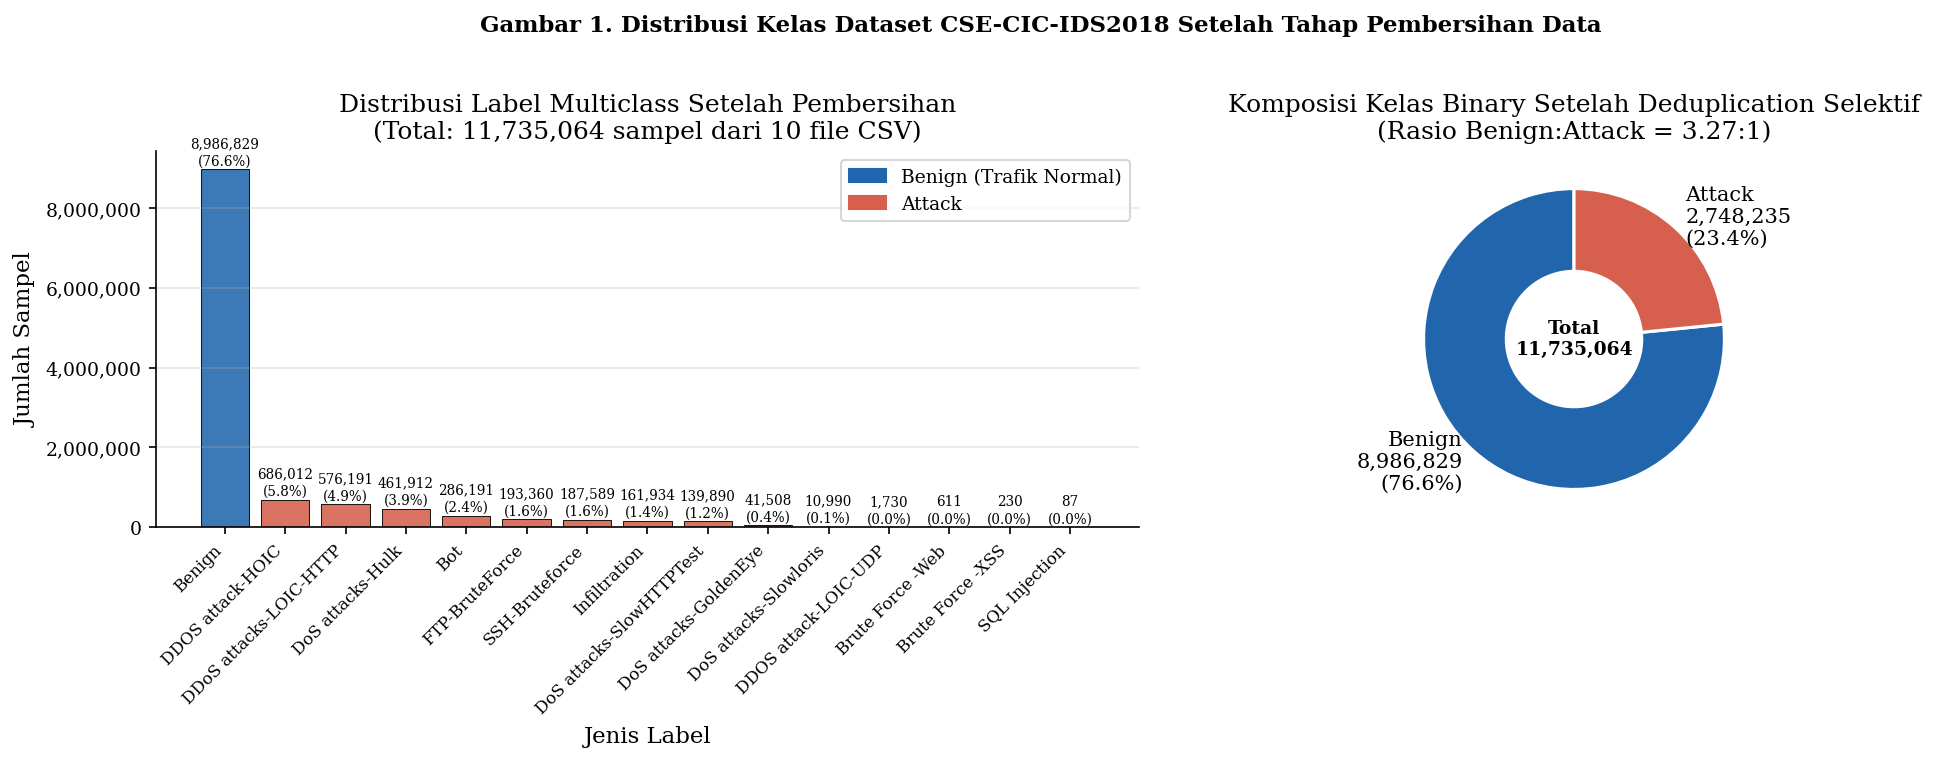

Benign: 8,986,829 (76.6%) | Attack: 2,748,235 (23.4%)
Rasio Benign:Attack = 3.27:1


8382

In [19]:
_dist = (
    final_df.group_by('Label')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .to_pandas()
)
_total = _dist['count'].sum()
_dist['pct']       = _dist['count'] / _total * 100
_dist['is_benign'] = _dist['Label'].str.lower() == 'benign'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri: bar chart per label
_clrs = [_CLR_BENIGN if b else _CLR_ATTACK for b in _dist['is_benign']]
_bars = axes[0].bar(
    _dist['Label'], _dist['count'],
    color=_clrs, edgecolor='black', linewidth=0.5, alpha=0.88
)
for _b, _v, _p in zip(_bars, _dist['count'], _dist['pct']):
    axes[0].text(
        _b.get_x() + _b.get_width()/2,
        _b.get_height() + _total*0.003,
        f'{_v:,}\n({_p:.1f}%)',
        ha='center', va='bottom', fontsize=6.5, linespacing=1.3
    )
axes[0].set_xticklabels(_dist['Label'], rotation=45, ha='right', fontsize=8)
axes[0].set_xlabel('Jenis Label')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_title(
    'Distribusi Label Multiclass Setelah Pembersihan\n'
    f'(Total: {_total:,} sampel dari 10 file CSV)'
)
axes[0].yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(handles=[
    mpatches.Patch(color=_CLR_BENIGN, label='Benign (Trafik Normal)'),
    mpatches.Patch(color=_CLR_ATTACK, label='Attack'),
], fontsize=9)

# Panel kanan: pie chart binary
_nb = int(_dist.loc[_dist['is_benign'],  'count'].sum())
_na = int(_dist.loc[~_dist['is_benign'], 'count'].sum())
axes[1].pie(
    [_nb, _na],
    labels=[f'Benign\n{_nb:,}\n({_nb/_total*100:.1f}%)',
            f'Attack\n{_na:,}\n({_na/_total*100:.1f}%)'],
    colors=[_CLR_BENIGN, _CLR_ATTACK],
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=10)
)
axes[1].text(0, 0, f'Total\n{_total:,}', ha='center', va='center',
             fontsize=9, fontweight='bold')
axes[1].set_title(
    'Komposisi Kelas Binary Setelah Deduplication Selektif\n'
    f'(Rasio Benign:Attack = {_nb/_na:.2f}:1)'
)

plt.suptitle(
    'Gambar 1. Distribusi Kelas Dataset CSE-CIC-IDS2018 Setelah Tahap Pembersihan Data',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(_SAVE_PATH, 'EDA_A_distribusi_kelas.png'))
plt.show()
print(f'Benign: {_nb:,} ({_nb/_total*100:.1f}%) | Attack: {_na:,} ({_na/_total*100:.1f}%)')
print(f'Rasio Benign:Attack = {_nb/_na:.2f}:1')
del _dist, _clrs, _bars, _b, _v, _p, _nb, _na
gc.collect()


---
## Sel 12 — Pembagian Data: Train / Validasi / Test (70:15:15)

In [20]:
print("Memuat checkpoint...")
df         = pl.read_parquet(checkpoint_path)
label_multi = df['Label'].to_pandas()
y_binary   = df['attack'].to_pandas()
X          = df.drop(['Label', 'attack']).to_pandas()
del df, final_df
gc.collect()

print("Membagi data 70% train — 30% ...")
X_train, X_temp, y_train, y_temp, lbl_train, lbl_temp = train_test_split(
    X, y_binary, label_multi,
    test_size=0.30, stratify=label_multi, random_state=RANDOM_STATE
)
del X, y_binary, label_multi
gc.collect()

print("Membagi 30% menjadi 15% validasi — 15% test...")
X_val, X_test, y_val, y_test, lbl_val, lbl_test = train_test_split(
    X_temp, y_temp, lbl_temp,
    test_size=0.50, stratify=lbl_temp, random_state=RANDOM_STATE
)
del X_temp, y_temp, lbl_temp
gc.collect()

total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"\nTraining set   : {X_train.shape[0]:,} baris ({X_train.shape[0]/total*100:.0f}%)")
print(f"Validation set : {X_val.shape[0]:,} baris ({X_val.shape[0]/total*100:.0f}%)")
print(f"Test set       : {X_test.shape[0]:,} baris ({X_test.shape[0]/total*100:.0f}%)")

print("\nDistribusi per jenis serangan pada Test Set:")
print(lbl_test.value_counts().sort_index().to_string())

Memuat checkpoint...
Membagi data 70% train — 30% ...
Membagi 30% menjadi 15% validasi — 15% test...

Training set   : 8,214,544 baris (70%)
Validation set : 1,760,260 baris (15%)
Test set       : 1,760,260 baris (15%)

Distribusi per jenis serangan pada Test Set:
Label
Benign                      1348024
Bot                           42928
Brute Force -Web                 92
Brute Force -XSS                 35
DDOS attack-HOIC             102902
DDOS attack-LOIC-UDP            260
DDoS attacks-LOIC-HTTP        86428
DoS attacks-GoldenEye          6227
DoS attacks-Hulk              69287
DoS attacks-SlowHTTPTest      20983
DoS attacks-Slowloris          1648
FTP-BruteForce                29004
Infiltration                  24290
SQL Injection                    13
SSH-Bruteforce                28139


---
## Sel 13 — Penghapusan Fitur Zero Variance

In [21]:
variances = X_train.var(axis=0)
zero_var  = variances[variances == 0].index.tolist()

print(f"Fitur zero-variance pada training set ({len(zero_var)}):")
for c in sorted(zero_var):
    print(f"  - {c}")

if zero_var:
    X_train = X_train.drop(columns=zero_var)
    X_val   = X_val.drop(columns=zero_var)
    X_test  = X_test.drop(columns=zero_var)
    print(f"\nShape training set : {X_train.shape}")

Fitur zero-variance pada training set (8):
  - Bwd Blk Rate Avg
  - Bwd Byts/b Avg
  - Bwd PSH Flags
  - Bwd Pkts/b Avg
  - Bwd URG Flags
  - Fwd Blk Rate Avg
  - Fwd Byts/b Avg
  - Fwd Pkts/b Avg

Shape training set : (8214544, 68)


---
## Sel 14 — Penghapusan Fitur yang Identik Secara Statistik

In [22]:
print("Mencari pasangan fitur yang identik pada training set...")
cols   = X_train.columns.tolist()
sample = X_train.sample(n=min(100_000, len(X_train)), random_state=RANDOM_STATE)

identical_pairs   = []
to_drop_identical = set()

for i, j in combinations(range(len(cols)), 2):
    c1, c2 = cols[i], cols[j]
    if c2 in to_drop_identical:
        continue
    if sample[c1].equals(sample[c2]):
        if X_train[c1].equals(X_train[c2]):
            identical_pairs.append((c1, c2))
            to_drop_identical.add(c2)

print(f"Pasangan fitur identik ditemukan ({len(identical_pairs)}):")
for c1, c2 in identical_pairs:
    print(f"  {c1}  ==  {c2}  -> hapus: {c2}")

to_drop_identical = list(to_drop_identical)
if to_drop_identical:
    X_train = X_train.drop(columns=to_drop_identical)
    X_val   = X_val.drop(columns=to_drop_identical)
    X_test  = X_test.drop(columns=to_drop_identical)
    print(f"\nShape training set : {X_train.shape}")

del sample
gc.collect()

Mencari pasangan fitur yang identik pada training set...
Pasangan fitur identik ditemukan (7):
  Bwd Pkt Len Mean  ==  Bwd Seg Size Avg  -> hapus: Bwd Seg Size Avg
  CWE Flag Count  ==  Fwd URG Flags  -> hapus: Fwd URG Flags
  Fwd PSH Flags  ==  SYN Flag Cnt  -> hapus: SYN Flag Cnt
  Fwd Pkt Len Mean  ==  Fwd Seg Size Avg  -> hapus: Fwd Seg Size Avg
  Subflow Bwd Pkts  ==  Tot Bwd Pkts  -> hapus: Tot Bwd Pkts
  Subflow Fwd Byts  ==  TotLen Fwd Pkts  -> hapus: TotLen Fwd Pkts
  Subflow Fwd Pkts  ==  Tot Fwd Pkts  -> hapus: Tot Fwd Pkts

Shape training set : (8214544, 61)


0

---
## Sel 15 — Penghapusan Fitur Berkorelasi Tinggi (Threshold r > 0,92)

In [23]:
print("Menghitung matriks korelasi pada training set ...")
np.random.seed(RANDOM_STATE)
corr_sample_size = min(2_000_000, len(X_train))
_, corr_sample = train_test_split(
    X_train,
    test_size=corr_sample_size,
    stratify=lbl_train,
    random_state=RANDOM_STATE
)

corr = corr_sample.corr().abs()
del corr_sample
gc.collect()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

threshold    = 0.92
to_drop_corr = set()
pairs_found  = []

for c1 in sorted(upper.columns):
    for c2 in sorted(upper.index):
        val = upper.loc[c2, c1]
        if pd.isna(val) or val <= threshold:
            continue
        if c1 in to_drop_corr or c2 in to_drop_corr:
            continue
        avg1     = corr[c1].drop(c1).mean()
        avg2     = corr[c2].drop(c2).mean()
        if avg1 == avg2:
            drop_col = max(c1, c2)
        else:
            drop_col = c1 if avg1 < avg2 else c2
        to_drop_corr.add(drop_col)
        pairs_found.append((c1, c2, val, drop_col))

print(f"Pasangan berkorelasi tinggi (r > {threshold}): {len(pairs_found)}")
print(f"\n{'Fitur 1':<25} {'Fitur 2':<25} {'r':>6}  Dihapus")
print("-" * 70)
for c1, c2, val, dropped in sorted(pairs_found, key=lambda x: -x[2]):
    print(f"{c1:<25} {c2:<25} {val:>6.3f}  {dropped}")

to_drop_corr = list(to_drop_corr)
print(f"\nTotal fitur dihapus: {len(to_drop_corr)}")

if to_drop_corr:
    X_train = X_train.drop(columns=to_drop_corr)
    X_val   = X_val.drop(columns=to_drop_corr)
    X_test  = X_test.drop(columns=to_drop_corr)
    print(f"Shape training set : {X_train.shape}")

with open(os.path.join(dataset_path, "dropped_features_correlation.txt"), "w") as f:
    f.write("\n".join(sorted(to_drop_corr)))

del corr, upper
gc.collect()

print(f"\nFitur final ({X_train.shape[1]} fitur):")
for i, c in enumerate(sorted(X_train.columns), 1):
    print(f"  {i:2d}. {c}")

Menghitung matriks korelasi pada training set ...
Pasangan berkorelasi tinggi (r > 0.92): 23

Fitur 1                   Fitur 2                        r  Dihapus
----------------------------------------------------------------------
RST Flag Cnt              ECE Flag Cnt               1.000  ECE Flag Cnt
Fwd IAT Tot               Flow Duration              0.996  Fwd IAT Tot
Pkt Size Avg              Pkt Len Mean               0.996  Pkt Size Avg
Subflow Fwd Pkts          Fwd Header Len             0.995  Subflow Fwd Pkts
Idle Mean                 Idle Max                   0.995  Idle Mean
Subflow Bwd Pkts          Bwd Header Len             0.995  Subflow Bwd Pkts
Subflow Bwd Byts          Bwd Header Len             0.995  Subflow Bwd Byts
TotLen Bwd Pkts           Bwd Header Len             0.995  TotLen Bwd Pkts
Fwd Header Len            Fwd Act Data Pkts          0.992  Fwd Act Data Pkts
Flow IAT Min              Flow IAT Mean              0.991  Flow IAT Mean
Fwd IAT Max         

---
## EDA-B — Analisis Fitur Setelah Seleksi (Sebelum Normalisasi)
Setelah seleksi fitur menghasilkan **`X_train.shape[1]` fitur final**, analisis berikut dilakukan pada data *pre-scaling*. Dua visualisasi disajikan: (1) *correlation heatmap* untuk memverifikasi tidak ada pasangan fitur dengan korelasi residual > 0.92, dan (2) boxplot distribusi nilai asli fitur-fitur dengan variansi tertinggi untuk mengkonfirmasi daya diskriminatif antara kelas Benign dan Attack.

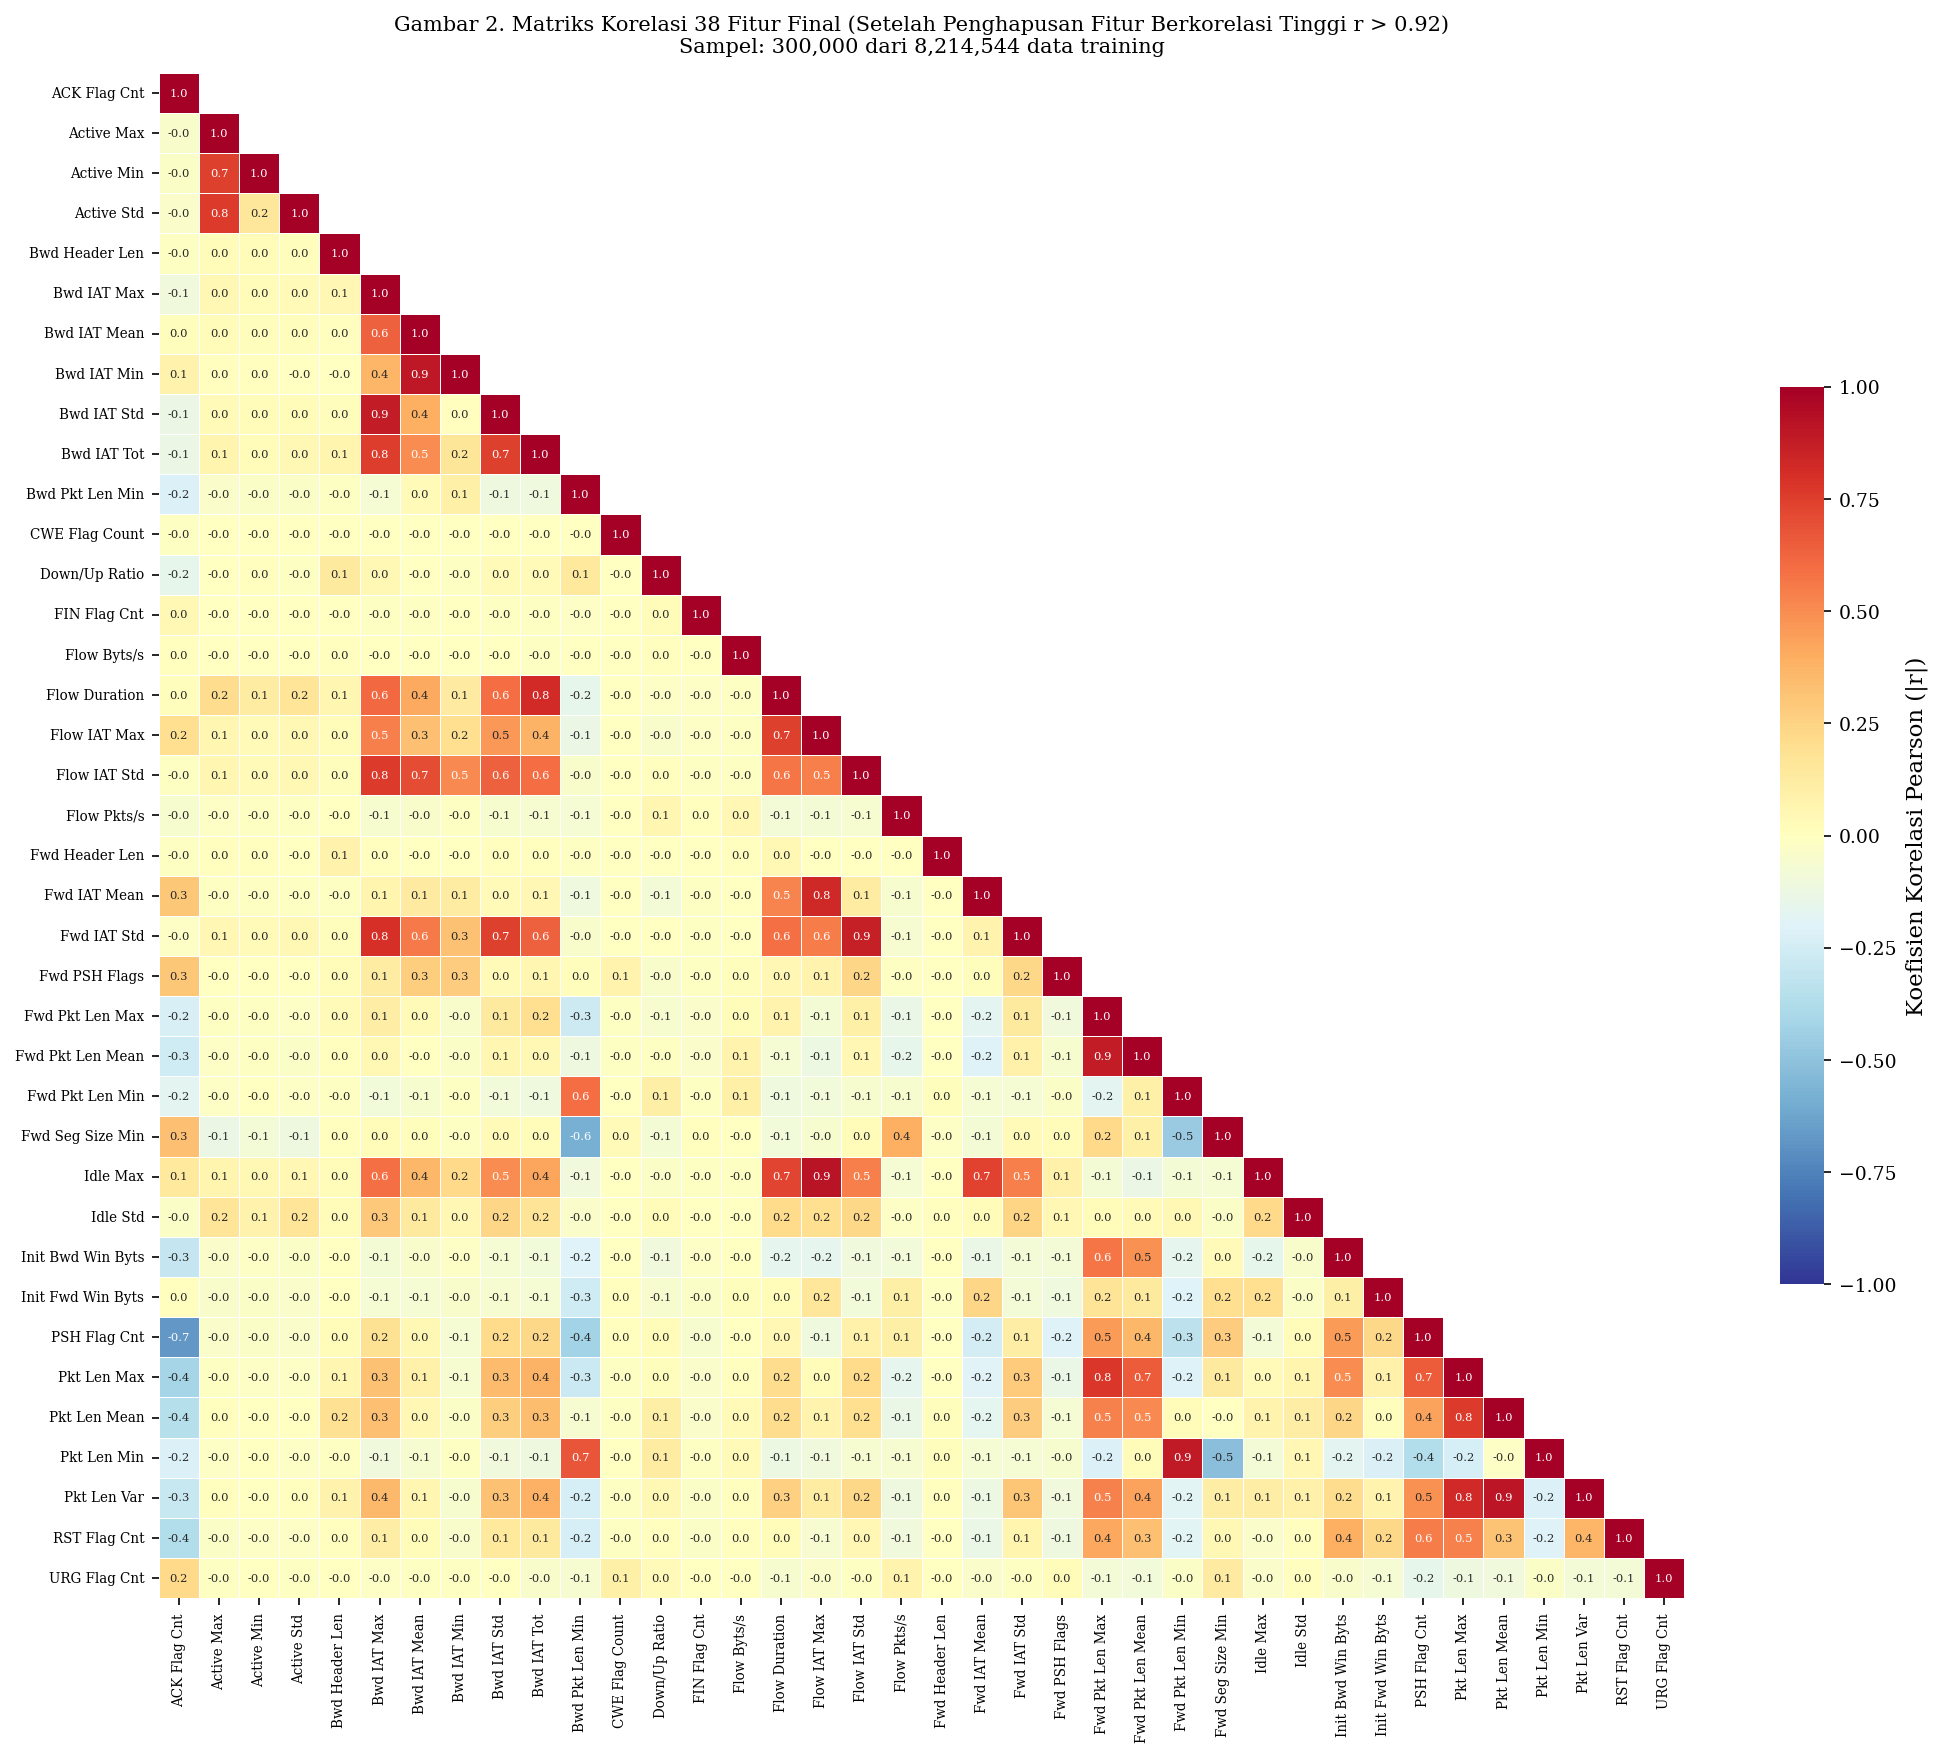

Korelasi residual maksimum: 0.9143  (harus < 0.92)


3

In [24]:
_feat_names = X_train.columns.tolist()
_n_feat     = len(_feat_names)

# Correlation Heatmap
_CORR_N   = min(300_000, len(X_train))
np.random.seed(RANDOM_STATE)
_idx_c    = np.random.choice(len(X_train), _CORR_N, replace=False)
_corr_mat = X_train.iloc[_idx_c].corr()

fig, ax = plt.subplots(figsize=(14, 12))
_mask = np.zeros_like(_corr_mat.values, dtype=bool)
_mask[np.triu_indices_from(_mask, k=1)] = True
sns.heatmap(
    _corr_mat, ax=ax, mask=_mask,
    cmap='RdYlBu_r', vmin=-1, vmax=1, center=0,
    annot=True, fmt='.1f',
    annot_kws={'size': 5.5},
    linewidths=0.25, square=True,
    cbar_kws={'shrink': 0.55, 'label': 'Koefisien Korelasi Pearson (|r|)'}
)
ax.set_xticklabels(_feat_names, rotation=90, fontsize=6.5)
ax.set_yticklabels(_feat_names, rotation=0,  fontsize=6.5)
ax.set_title(
    f'Gambar 2. Matriks Korelasi {_n_feat} Fitur Final '
    f'(Setelah Penghapusan Fitur Berkorelasi Tinggi r > 0.92)\n'
    f'Sampel: {_CORR_N:,} dari {len(X_train):,} data training',
    fontsize=10, pad=10
)
plt.tight_layout()
plt.savefig(os.path.join(_SAVE_PATH, 'EDA_B1_correlation_heatmap.png'))
plt.show()

_upper = _corr_mat.abs().where(np.triu(np.ones(_corr_mat.shape), k=1).astype(bool))
print(f'Korelasi residual maksimum: {_upper.max().max():.4f}  (harus < 0.92)')

del _corr_mat, _idx_c, _mask, _upper, _feat_names
gc.collect()

---
## Sel 16 — Normalisasi Fitur: QuantileTransformer

In [ ]:
print("=== VERIFIKASI DAN PEMBERSIHAN NaN ===")
nan_train = X_train.isna().sum().sum()
nan_val   = X_val.isna().sum().sum()
nan_test  = X_test.isna().sum().sum()
print(f"NaN — Train: {nan_train:,} | Val: {nan_val:,} | Test: {nan_test:,}")

if nan_train > 0 or nan_val > 0 or nan_test > 0:
    X_train   = X_train.dropna()
    y_train   = y_train.loc[X_train.index]
    lbl_train = lbl_train.loc[X_train.index]

    X_val   = X_val.dropna()
    y_val   = y_val.loc[X_val.index]
    lbl_val = lbl_val.loc[X_val.index]

    X_test   = X_test.dropna()
    y_test   = y_test.loc[X_test.index]
    lbl_test = lbl_test.loc[X_test.index]

    print(f"Shape setelah drop NaN:")
    print(f"  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
    print(f"  NaN tersisa: {X_train.isna().sum().sum()} | Inf: {np.isinf(X_train.values).sum()}")

print("\n=== NORMALISASI: QUANTILE TRANSFORMER ===")
sample_size = min(200_000, len(X_train))
print(f"Stratified sampling {sample_size:,} baris untuk fitting...")

_, fit_sample = train_test_split(
    X_train, test_size=sample_size,
    stratify=lbl_train, random_state=RANDOM_STATE
)

qt = QuantileTransformer(
    output_distribution='uniform',
    n_quantiles=10_000,
    subsample=sample_size,
    random_state=RANDOM_STATE
)
qt.fit(fit_sample)
del fit_sample
gc.collect()

print("Mentransformasi training set...")
X_train_scaled = qt.transform(X_train).astype(np.float32)
print("Mentransformasi validation set...")
X_val_scaled   = qt.transform(X_val).astype(np.float32)
print("Mentransformasi test set...")
X_test_scaled  = qt.transform(X_test).astype(np.float32)

joblib.dump(qt, os.path.join(dataset_path, "quantile_transformer.pkl"))

print(f"\nShape scaled  : {X_train_scaled.shape}")
print(f"Range         : [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
print(f"Mean          : {X_train_scaled.mean():.4f}")
print(f"Std           : {X_train_scaled.std():.4f}")
print(f"NaN di scaled : {np.isnan(X_train_scaled).sum()}")

=== VERIFIKASI DAN PEMBERSIHAN NaN ===
NaN — Train: 1,874 | Val: 373 | Test: 412
Shape setelah drop NaN:
  Train: (8212670, 38) | Val: (1759887, 38) | Test: (1759848, 38)
  NaN tersisa: 0 | Inf: 0

=== NORMALISASI: QUANTILE TRANSFORMER ===
Stratified sampling 200,000 baris untuk fitting...
Mentransformasi training set...
Mentransformasi validation set...
Mentransformasi test set...

Shape scaled  : (8212670, 38)
Range         : [0.0000, 1.0000]
Mean          : 0.3297
Std           : 0.3734
NaN di scaled : 0


---
## Sel 17 — Penghitungan Bobot Kelas

In [ ]:
weights          = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_train.values), y=y_train.values
)
class_weights    = {0: float(weights[0]), 1: float(weights[1])}
n_benign_train   = (y_train.values == 0).sum()
n_attack_train   = (y_train.values == 1).sum()
scale_pos_weight = float(n_benign_train / n_attack_train)

print(f"Jumlah Benign (train)    : {n_benign_train:,}")
print(f"Jumlah Attack (train)    : {n_attack_train:,}")
print(f"Rasio Benign:Attack      : {scale_pos_weight:.4f}:1")
print(f"\nclass_weights (MLP/AE)   : {class_weights}")
print(f"scale_pos_weight (LGBM)  : {scale_pos_weight:.4f}")

Jumlah Benign (train)    : 6,289,506
Jumlah Attack (train)    : 1,923,164
Rasio Benign:Attack      : 3.2704:1

class_weights (MLP/AE)   : {0: 0.6528867291008229, 1: 2.135197518256373}
scale_pos_weight (LGBM)  : 3.2704


---
## Sel 18 — Penyimpanan Artifact

In [ ]:
dataset_split = {
    'X_train'          : X_train_scaled,
    'y_train'          : y_train.values,
    'X_val'            : X_val_scaled,
    'y_val'            : y_val.values,
    'X_test'           : X_test_scaled,
    'y_test'           : y_test.values,
    'label_train'      : lbl_train.values,
    'label_val'        : lbl_val.values,
    'label_test'       : lbl_test.values,
    'features'         : X_train.columns.tolist(),
    'n_features'       : X_train.shape[1],
    'class_weights'    : class_weights,
    'scale_pos_weight' : scale_pos_weight,
}

output_file = os.path.join(dataset_path, "dataset_split.joblib")
joblib.dump(dataset_split, output_file, compress=3)
print(f"Tersimpan : {output_file}")

with open(os.path.join(dataset_path, "selected_features.txt"), "w") as f:
    f.write("\n".join(X_train.columns.tolist()))
print("Tersimpan : selected_features.txt")

Tersimpan : /content/drive/MyDrive/Colab Notebooks/dataset_split.joblib
Tersimpan : selected_features.txt


---
## Sel 19 — Ringkasan dan Validasi Kesiapan Data

In [ ]:
print("=" * 65)
print(" PREPROCESSING SELESAI — CSE-CIC-IDS2018")
print("=" * 65)

print(f"\n{'Parameter':<35} {'Nilai'}")
print("-" * 55)
print(f"{'Jumlah fitur final':<35} {X_train.shape[1]}")
print(f"{'Training set':<35} {X_train_scaled.shape[0]:,} baris")
print(f"{'Validation set':<35} {X_val_scaled.shape[0]:,} baris")
print(f"{'Test set':<35} {X_test_scaled.shape[0]:,} baris")
print(f"{'Rasio Benign:Attack (train)':<35} {n_benign_train/n_attack_train:.2f}:1")
print(f"{'class_weights Benign':<35} {class_weights[0]:.4f}")
print(f"{'class_weights Attack':<35} {class_weights[1]:.4f}")
print(f"{'scale_pos_weight (LightGBM)':<35} {scale_pos_weight:.4f}")

print("\n--- Validasi Target Sistem ---")
total_benign_test = (y_test.values == 0).sum()
total_attack_test = (y_test.values == 1).sum()
max_fp = int(total_benign_test * 0.02)
print(f"Target F1 >= 85% (binary):")
print(f"  Sampel Attack di test : {total_attack_test:,}")
print(f"  Sampel Benign di test : {total_benign_test:,}")

print("\n--- Kesiapan Evaluasi Per Jenis Serangan (Test Set) ---")
print(f"  {'Jenis Serangan':<35} {'Sampel':>8}  Status")
print("  " + "-" * 58)
for lbl_name, cnt in sorted(lbl_test.value_counts().items()):
    status = "Cukup" if cnt >= 30 else "< 30 sampel"
    print(f"  {lbl_name:<35} {cnt:>8,}  {status}")

print("\n--- Verifikasi Kualitas Data Akhir ---")
print(f"  NaN di X_train_scaled : {np.isnan(X_train_scaled).sum()}")
print(f"  NaN di X_val_scaled   : {np.isnan(X_val_scaled).sum()}")
print(f"  NaN di X_test_scaled  : {np.isnan(X_test_scaled).sum()}")
print(f"  Range X_train_scaled  : [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")

print("\n--- File yang Disimpan ---")
for fname in [
    "dataset_split.joblib",
    "quantile_transformer.pkl",
    "cicids2018_cleaned.parquet",
    "selected_features.txt",
    "dropped_features_correlation.txt",
]:
    print(f"  v  {fname}")

 PREPROCESSING SELESAI — CSE-CIC-IDS2018

Parameter                           Nilai
-------------------------------------------------------
Jumlah fitur final                  38
Training set                        8,212,670 baris
Validation set                      1,759,887 baris
Test set                            1,759,848 baris
Rasio Benign:Attack (train)         3.27:1
class_weights Benign                0.6529
class_weights Attack                2.1352
scale_pos_weight (LightGBM)         3.2704

--- Validasi Target Sistem ---
Target F1 >= 85% (binary):
  Sampel Attack di test : 412,126
  Sampel Benign di test : 1,347,722

--- Kesiapan Evaluasi Per Jenis Serangan (Test Set) ---
  Jenis Serangan                        Sampel  Status
  ----------------------------------------------------------
  Benign                              1,347,722  Cukup
  Bot                                   42,928  Cukup
  Brute Force -Web                          92  Cukup
  Brute Force -XSS          